# 🛒 Customer Lifetime Value (LTV) Prediction Model
**Objective:** Predict the future spending of customers based on their historical purchase behavior to aid in targeted marketing.

**Tools:** Python (Pandas, Sklearn, XGBoost, Seaborn, Matplotlib)

**Dataset:** [Online Retail Dataset – UCI / Kaggle](https://www.kaggle.com/datasets/vijayuv/onlineretail)

---
### Project Flow
1. Setup & Imports
2. Load & Clean Data
3. Timeline Split (Feature Window vs Target Window)
4. Feature Engineering (RFM + extras)
5. Build Target Variable (Future LTV)
6. Model Training (XGBoost + Random Forest)
7. Model Validation (MAE, RMSE)
8. Customer Segmentation by Predicted LTV
9. Visualizations
10. Export Deliverables

---
## Step 1: Setup & Imports
Install any missing packages by running: `!pip install xgboost openpyxl`

In [1]:
# Uncomment below if running in Google Colab
#!pip install xgboost openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Step 2: Load & Clean Data

**How to get the dataset:**
1. Go to [Kaggle – Online Retail Dataset](https://www.kaggle.com/datasets/vijayuv/onlineretail)
2. Download `OnlineRetail.xlsx`
3. Upload it to your Colab session (or place it in the same folder as this notebook)

**Columns you'll see:**
- `InvoiceNo` — Transaction ID
- `StockCode` — Product code
- `Description` — Product name
- `Quantity` — Units purchased
- `InvoiceDate` — Date & time of transaction
- `UnitPrice` — Price per unit (GBP)
- `CustomerID` — Unique customer identifier
- `Country` — Customer's country

In [3]:
# ── Load the dataset ──────────────────────────────────────────────
# If CSV version: df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

print('Shape before cleaning:', df.shape)
df.head()

Shape before cleaning: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# ── Clean the data ────────────────────────────────────────────────

# 1. Drop rows with missing CustomerID (anonymous/guest transactions)
df = df.dropna(subset=['CustomerID'])

# 2. Remove returns and cancellations (Quantity or UnitPrice <= 0)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# 3. Fix data types
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 4. Create revenue column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print('Shape after cleaning:', df.shape)
print('Date range:', df['InvoiceDate'].min(), '→', df['InvoiceDate'].max())
print('Unique customers:', df['CustomerID'].nunique())
df.info()

Shape after cleaning: (397884, 9)
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Unique customers: 4338
<class 'pandas.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  str           
 1   StockCode    397884 non-null  str           
 2   Description  397884 non-null  str           
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[us]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  str           
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 49.9 MB


---
## Step 3: Timeline Split — Feature Window vs Target Window

**Why do this?**
We want to simulate a real-world scenario:
- We observe each customer's behavior for the **first 6 months** → these become our **features (inputs)**
- We observe how much they spent in the **next 6 months** → this becomes our **target (what we predict)**

This makes it a genuine prediction problem, not just a historical aggregation.

In [5]:
# ── Define the cutoff date ────────────────────────────────────────
min_date = df['InvoiceDate'].min()
max_date = df['InvoiceDate'].max()

# Midpoint cutoff — first half = features, second half = target
cutoff_date = min_date + (max_date - min_date) / 2

print(f'Dataset range : {min_date.date()} → {max_date.date()}')
print(f'Cutoff date   : {cutoff_date.date()}')
print(f'Feature window: {min_date.date()} → {cutoff_date.date()}')
print(f'Target window : {cutoff_date.date()} → {max_date.date()}')

features_df = df[df['InvoiceDate'] <= cutoff_date].copy()
target_df   = df[df['InvoiceDate'] >  cutoff_date].copy()

print(f'\nTransactions in feature window : {len(features_df):,}')
print(f'Transactions in target window  : {len(target_df):,}')

Dataset range : 2010-12-01 → 2011-12-09
Cutoff date   : 2011-06-05
Feature window: 2010-12-01 → 2011-06-05
Target window : 2011-06-05 → 2011-12-09

Transactions in feature window : 149,388
Transactions in target window  : 248,496


---
## Step 4: Feature Engineering — RFM + Extra Features

We build features from the **feature window only** (first half of data):

| Feature | What it measures |
|---|---|
| **Recency** | Days since last purchase (lower = more engaged) |
| **Frequency** | Number of unique orders placed |
| **Monetary** | Total spend in the feature window |
| **AOV** | Average order value (Monetary / Frequency) |
| **Tenure** | Days since first purchase (loyalty indicator) |
| **AvgQuantity** | Average items per transaction |
| **UniqueProducts** | Variety of products bought |

In [6]:
# ── Build RFM + extra features ────────────────────────────────────
snapshot_date = cutoff_date + pd.Timedelta(days=1)

rfm = features_df.groupby('CustomerID').agg(
    Recency       = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency     = ('InvoiceNo',    'nunique'),
    Monetary      = ('TotalPrice',   'sum'),
    AvgQuantity   = ('Quantity',     'mean'),
    UniqueProducts= ('StockCode',    'nunique'),
    Tenure        = ('InvoiceDate',  lambda x: (snapshot_date - x.min()).days)
).reset_index()

# AOV = Monetary / Frequency
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

print('Feature matrix shape:', rfm.shape)
rfm.describe().round(2)

Feature matrix shape: (2754, 8)


,CustomerID,Recency,Frequency,Monetary,AvgQuantity,UniqueProducts,Tenure,AOV
count,2754.00,2754.00,2754.00,2754.00,2754.00,2754.00,2754.00,2754.00
mean,15292.87,66.04,2.76,1240.66,51.56,42.08,115.93,405.86
std,1714.26,53.54,4.08,4180.96,1421.29,54.97,55.93,1541.48
min,12346.00,1.00,1.00,2.90,1.00,1.00,1.00,2.90
25%,13819.50,21.00,1.00,243.44,5.76,12.00,71.00,171.66
50%,15242.50,53.00,2.00,479.25,9.52,26.00,122.00,291.97
75%,16765.75,101.00,3.00,1084.99,14.28,53.00,174.00,422.51
max,18287.00,187.00,86.00,116135.92,74215.00,881.00,187.00,77183.60


---
## Step 5: Build the Target Variable — Future LTV

The target variable is **how much each customer spent in the second half** of the dataset.
Customers who made no purchases in the target window get **LTV = 0** (they churned).

Final dataset shape: (2754, 9)
Customers with future purchases : 1935
Customers with LTV = 0 (churned): 819


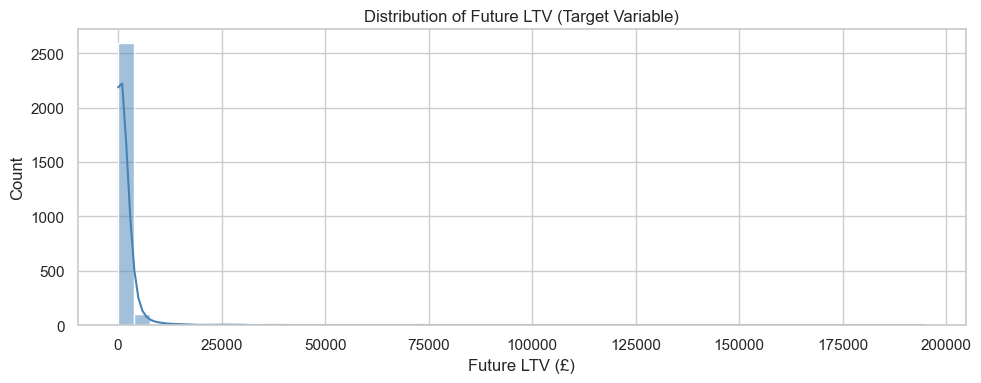

In [7]:
# ── Calculate future LTV from target window ───────────────────────
future_value = (
    target_df
    .groupby('CustomerID')['TotalPrice']
    .sum()
    .reset_index()
    .rename(columns={'TotalPrice': 'FutureLTV'})
)

# Merge with RFM features — left join so all feature-window customers are kept
model_df = rfm.merge(future_value, on='CustomerID', how='left')
model_df['FutureLTV'] = model_df['FutureLTV'].fillna(0)  # no future purchase = 0

print('Final dataset shape:', model_df.shape)
print(f'Customers with future purchases : {(model_df["FutureLTV"] > 0).sum()}')
print(f'Customers with LTV = 0 (churned): {(model_df["FutureLTV"] == 0).sum()}')

# Quick distribution check
plt.figure(figsize=(10, 4))
sns.histplot(model_df['FutureLTV'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Future LTV (Target Variable)')
plt.xlabel('Future LTV (£)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot_ltv_distribution.png', dpi=150)
plt.show()

---
## Step 6: Model Training — XGBoost vs Random Forest

We train **both models** and compare their performance.
XGBoost typically wins on tabular data, but we document both for the report.

In [8]:
# ── Train / Test Split ────────────────────────────────────────────
FEATURES = ['Recency', 'Frequency', 'Monetary', 'AOV', 'AvgQuantity', 'UniqueProducts', 'Tenure']
TARGET   = 'FutureLTV'

X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set : {X_train.shape[0]} customers')
print(f'Test set     : {X_test.shape[0]} customers')

Training set : 2203 customers
Test set     : 551 customers


In [9]:
# ── Train XGBoost ─────────────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
print(f'XGBoost  →  MAE: £{xgb_mae:.2f}   |   RMSE: £{xgb_rmse:.2f}')

XGBoost  →  MAE: £849.85   |   RMSE: £2039.02


In [10]:
# ── Train Random Forest ───────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
print(f'Random Forest  →  MAE: £{rf_mae:.2f}   |   RMSE: £{rf_rmse:.2f}')

# ── Pick the best model ───────────────────────────────────────────
if xgb_rmse <= rf_rmse:
    best_model = xgb_model
    best_preds = xgb_preds
    print('\n✅ Best model: XGBoost')
else:
    best_model = rf_model
    best_preds = rf_preds
    print('\n✅ Best model: Random Forest')

Random Forest  →  MAE: £794.94   |   RMSE: £1785.80

✅ Best model: Random Forest


---
## Step 7: Model Validation

Two key metrics:
- **MAE (Mean Absolute Error):** Average £ error per customer — easy to explain to stakeholders
- **RMSE (Root Mean Squared Error):** Penalizes large errors more — better for catching bad outlier predictions

        Model    MAE (£)    RMSE (£)
      XGBoost 849.850238 2039.016215
Random Forest 794.936207 1785.796186


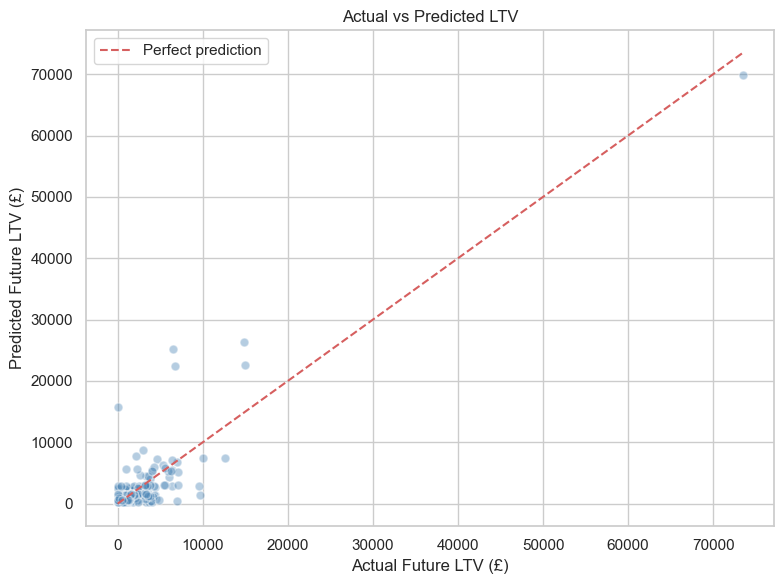

In [11]:
# ── Comparison Table ──────────────────────────────────────────────
results = pd.DataFrame({
    'Model'  : ['XGBoost', 'Random Forest'],
    'MAE (£)': [xgb_mae,  rf_mae],
    'RMSE (£)': [xgb_rmse, rf_rmse]
})
print(results.to_string(index=False))

# ── Actual vs Predicted Plot ──────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.4, color='steelblue', edgecolors='white', s=40)
max_val = max(y_test.max(), best_preds.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Future LTV (£)')
plt.ylabel('Predicted Future LTV (£)')
plt.title('Actual vs Predicted LTV')
plt.legend()
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=150)
plt.show()

---
## Step 8: Customer Segmentation by Predicted LTV

Divide all customers into **4 segments** based on their predicted LTV:

| Segment | Description | Marketing Action |
|---|---|---|
| **VIP** | Top 25% predicted spenders | Loyalty rewards, exclusive offers |
| **High** | Next 25% | Upsell premium products |
| **Medium** | Next 25% | Re-engagement campaigns |
| **Low** | Bottom 25% | Low-cost retention or let go |

In [12]:
# ── Predict LTV for all customers & segment ───────────────────────
model_df['PredictedLTV'] = best_model.predict(X)
model_df['PredictedLTV'] = model_df['PredictedLTV'].clip(lower=0)  # no negative LTV

model_df['Segment'] = pd.qcut(
    model_df['PredictedLTV'],
    q=4,
    labels=['Low', 'Medium', 'High', 'VIP']
)

# Segment summary
segment_summary = model_df.groupby('Segment', observed=True).agg(
    CustomerCount  = ('CustomerID',   'count'),
    AvgPredictedLTV= ('PredictedLTV', 'mean'),
    AvgActualLTV   = ('FutureLTV',    'mean')
).round(2)

print(segment_summary)

         CustomerCount  AvgPredictedLTV  AvgActualLTV
Segment                                              
Low                693           303.84        221.80
Medium             686           397.51        423.29
High               686           839.78        840.94
VIP                689          4733.91       4727.39


---
## Step 9: Visualizations

Four key charts for your portfolio / report:

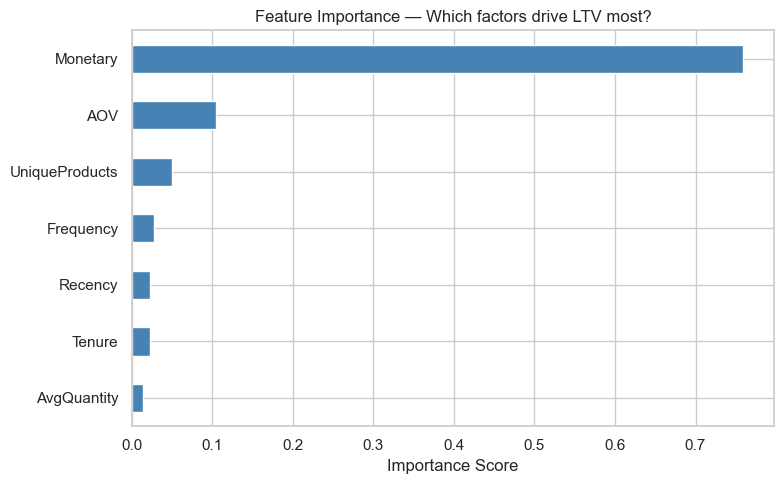

In [13]:
# ── Chart 1: Feature Importance ───────────────────────────────────
importances = pd.Series(
    best_model.feature_importances_, index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Which factors drive LTV most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()

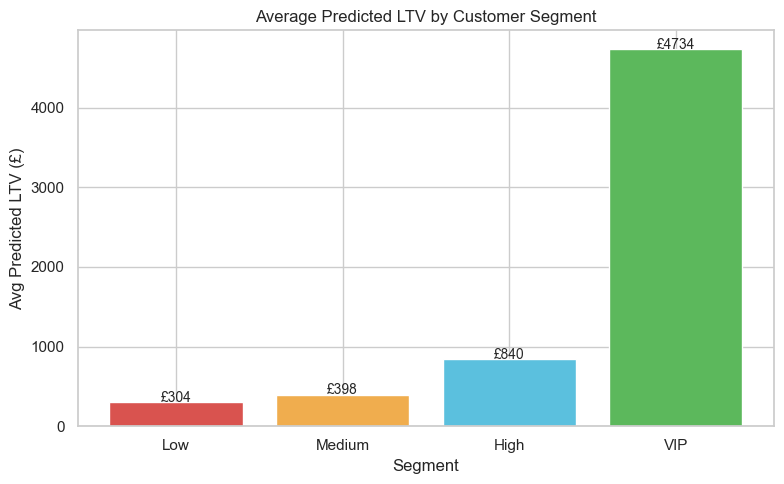

In [14]:
# ── Chart 2: Average LTV by Segment ──────────────────────────────
plt.figure(figsize=(8, 5))
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']
bars = plt.bar(
    segment_summary.index,
    segment_summary['AvgPredictedLTV'],
    color=colors, edgecolor='white'
)
plt.title('Average Predicted LTV by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Avg Predicted LTV (£)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'£{bar.get_height():.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_segment_ltv.png', dpi=150)
plt.show()

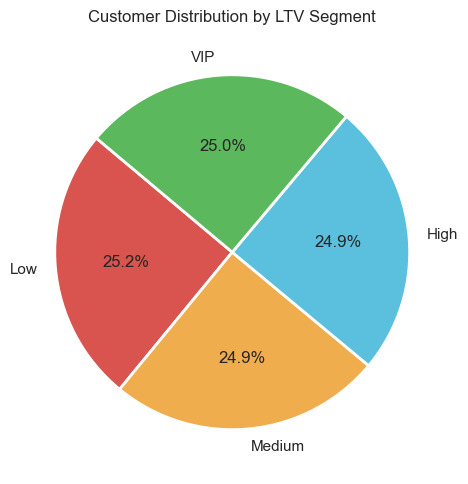

In [15]:
# ── Chart 3: Customer Count per Segment ──────────────────────────
plt.figure(figsize=(7, 5))
plt.pie(
    segment_summary['CustomerCount'],
    labels=segment_summary.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Customer Distribution by LTV Segment')
plt.tight_layout()
plt.savefig('plot_segment_distribution.png', dpi=150)
plt.show()

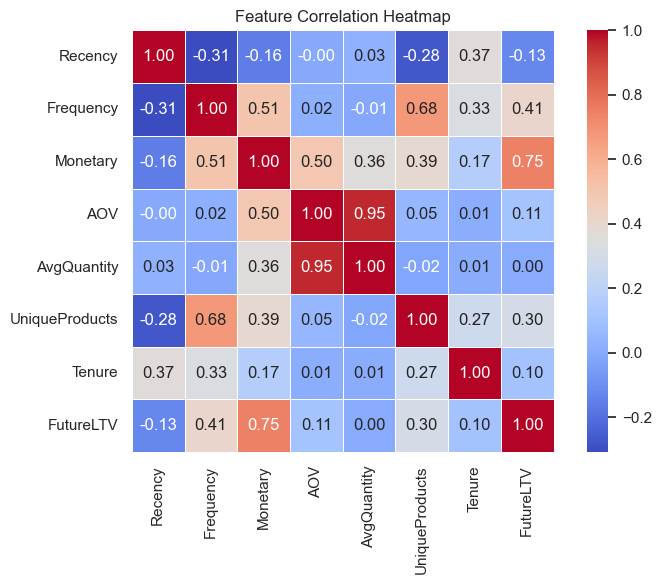

In [16]:
# ── Chart 4: RFM Correlation Heatmap ─────────────────────────────
plt.figure(figsize=(8, 6))
corr = model_df[FEATURES + ['FutureLTV']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150)
plt.show()

---
## Step 10: Export Deliverables

Three files to save:
1. **Final_LTV_Predictions.csv** — customer-level predictions + segments
2. **ltv_model.pkl** — trained model file (reusable)
3. **Segment_Summary.csv** — aggregated segment-level summary (open this in Excel for pivot table)

In [17]:
# ── 1. Final predictions CSV ──────────────────────────────────────
output_cols = ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AOV',
               'Tenure', 'FutureLTV', 'PredictedLTV', 'Segment']
final_output = model_df[output_cols].copy()
final_output.to_csv('Final_LTV_Predictions.csv', index=False)
print('✅ Final_LTV_Predictions.csv saved')

# ── 2. Save trained model ─────────────────────────────────────────
joblib.dump(best_model, 'ltv_model.pkl')
print('✅ ltv_model.pkl saved')

# ── 3. Segment summary CSV (for Excel pivot table) ────────────────
segment_summary.to_csv('Segment_Summary.csv')
print('✅ Segment_Summary.csv saved')

print('\n📁 All deliverables exported successfully!')
print('\n📊 Next step: Open Segment_Summary.csv in Excel')
print('   → Insert → PivotTable → compare AvgPredictedLTV vs AvgActualLTV per segment')

✅ Final_LTV_Predictions.csv saved
✅ ltv_model.pkl saved
✅ Segment_Summary.csv saved

📁 All deliverables exported successfully!

📊 Next step: Open Segment_Summary.csv in Excel
   → Insert → PivotTable → compare AvgPredictedLTV vs AvgActualLTV per segment


---
## 📋 Project Summary

### What we built
A machine learning model that predicts how much each customer will spend in the next period, using their historical purchase behavior (RFM + tenure + product variety).

### Key findings to write in your report
- **Most important feature:** Check the Feature Importance chart — typically `Monetary` or `Frequency` dominates
- **Model performance:** Fill in your MAE and RMSE values from Step 7
- **VIP customers:** Check how many are in the VIP segment and their average predicted LTV

### Marketing recommendations (customize with your actual numbers)
1. **VIP segment** → Invest in exclusive loyalty programs; highest ROI per marketing ₹ spent
2. **High segment** → Upsell campaigns with premium product recommendations
3. **Medium segment** → Re-engagement emails with personalized offers
4. **Low segment** → Low-cost retention (push notifications only); evaluate if worth retaining

---
*Project by: [ARCHITHA K] | Dataset: UCI Online Retail | Tools: Python, XGBoost, Sklearn, Seaborn*